<div style="background: linear-gradient(135deg, rgba(10, 15, 26, 0.92) 0%, rgba(15, 23, 42, 0.95) 100%), url('https://images.unsplash.com/photo-1526778548025-fa2f459cd5c1?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 35px; border-radius: 20px; border: 2px solid #0284C7; box-shadow: 0 10px 30px rgba(2, 132, 199, 0.25); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-bottom: 25px;">
    <div style="display: inline-block; background: rgba(2, 132, 199, 0.15); border: 1px solid #0284C7; padding: 6px 16px; border-radius: 50px; font-size: 13px; font-weight: 700; color: #38BDF8; letter-spacing: 1px; margin-bottom: 15px;">🌐 GLOBAL DEMOGRAPHIC ANALYTICS</div>
    <h1 style="color: #FFFFFF; font-size: 32px; font-weight: 800; margin: 0 0 10px 0; line-height: 1.2;">Wikipedia Country Statistics 2026 <span style="color: #0284C7;">| Lightning Analysis</span></h1>
    <p style="color: #CBD5E1; font-size: 15px; margin-bottom: 25px; max-width: 800px; line-height: 1.6;">A high-performance exploratory analysis and LightGBM model predicting Human Development Index (HDI) across 195 UN member and observer states using land area, population, and fertility metrics.</p>
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin-bottom: 30px;">
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #0284C7; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Data Source</div>
            <div style="font-size: 15px; font-weight: 700; color: #38BDF8;">Wikipedia 2026 Scraped</div>
        </div>
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #38BDF8; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Primary Target</div>
            <div style="font-size: 15px; font-weight: 700; color: #FFFFFF;">Human Development Index (HDI)</div>
        </div>
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #0284C7; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Runtime Optimization</div>
            <div style="font-size: 15px; font-weight: 700; color: #38BDF8;">Ultra-Fast CPU Pipeline</div>
        </div>
    </div>
    <div style="background: rgba(10, 15, 26, 0.85); border: 1px solid rgba(2, 132, 199, 0.3); border-radius: 12px; padding: 20px;">
        <h3 style="color: #38BDF8; font-size: 16px; font-weight: 700; margin: 0 0 15px 0; display: flex; align-items: center; gap: 8px;"> Table of Contents</h3>
        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 10px; font-size: 14px;">
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">1.</b> Environment & Automated String Cleaning</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">2.</b> Demographic & Geographic EDA</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">3.</b> Feature Engineering & Correlation Analytics</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">4.</b> LightGBM HDI Prediction Model</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">5.</b> Feature Importance & Insights</div>
        </div>
    </div>

## 1: Environment & Automated String Cleaning

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
import warnings 
warnings.filterwarnings('ignore')
# Set visualization parameters
sns.set_theme(style="darkgrid")
plt.rcParams["font.size"] = 11

# Find dataset file dynamically
DATA_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            DATA_PATH = os.path.join(root, file)
            break

if not DATA_PATH:
    DATA_PATH = 'country_stats.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")

# Standardize column headers
df.columns = df.columns.str.strip()

# Clean string numbers containing %, commas, or footnote brackets
def clean_numeric_series(series):
    return (
        series.astype(str)
        .str.replace(r'\[.*?\]', '', regex=True) # Remove footnotes like [1]
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )

for col in df.columns:
    if col != 'Country name':
        df[col] = pd.to_numeric(clean_numeric_series(df[col]), errors='coerce')

display(df.head())

Dataset Loaded Successfully! Shape: (195, 13)


,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47,13.27,95.6,299.0637
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33,8.17,94.4,3468.2119
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03,7.82,91.6,2412.0799
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63,8.42,94.7,30196.9610
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59,6.90,84.5,692.6895


## 2: Fast Demographic EDA

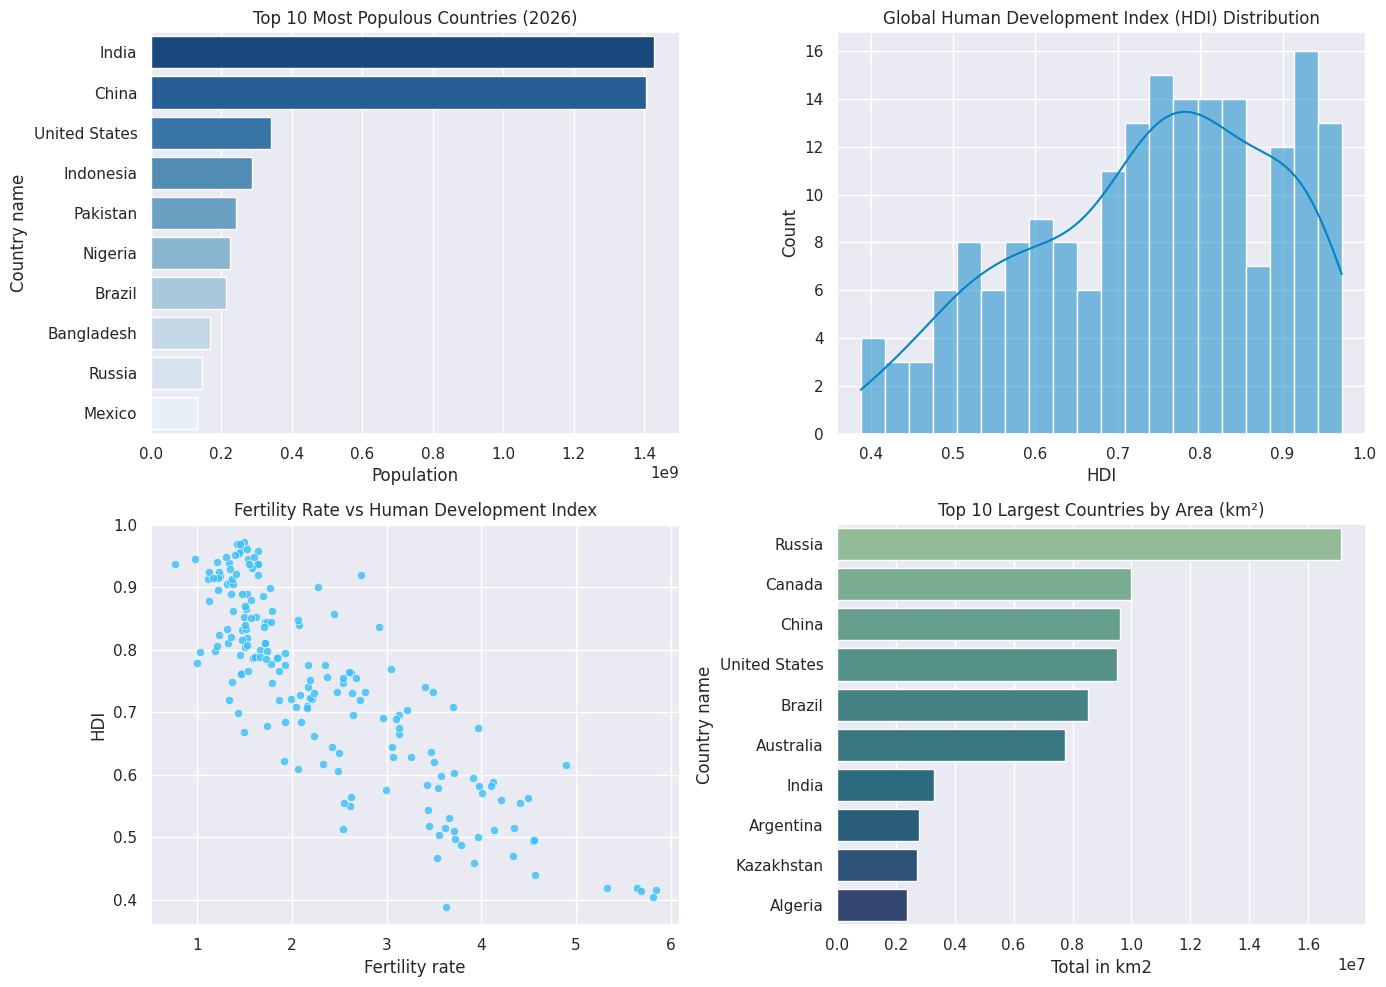

In [2]:
# Create 2x2 subplot layout for visual metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top 10 Countries by Population
top_pop = df.nlargest(10, 'Population')
sns.barplot(data=top_pop, y='Country name', x='Population', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 10 Most Populous Countries (2026)')
axes[0, 0].set_xlabel('Population')

# 2. HDI Distribution
sns.histplot(df['HDI'].dropna(), kde=True, ax=axes[0, 1], color='#0284C7', bins=20)
axes[0, 1].set_title('Global Human Development Index (HDI) Distribution')

# 3. Fertility Rate vs HDI
sns.scatterplot(data=df, x='Fertility rate', y='HDI', ax=axes[1, 0], color='#38BDF8', alpha=0.8)
axes[1, 0].set_title('Fertility Rate vs Human Development Index')

# 4. Land Area vs Water %
top_area = df.nlargest(10, 'Total in km2')
sns.barplot(data=top_area, y='Country name', x='Total in km2', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Top 10 Largest Countries by Area (km²)')

plt.tight_layout()
plt.show()

## 3: Feature Engineering & LightGBM HDI Regressor

--- 5-Fold Cross Validation Performance ---
R² Score : 0.7012
RMSE     : 0.0811


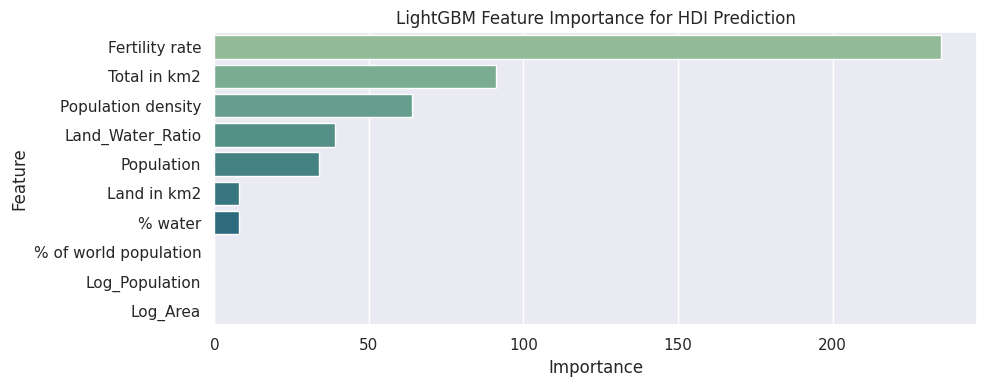

In [3]:
# Feature Engineering
df['Land_Water_Ratio'] = df['Land in km2'] / (df['Inland water in km2'] + 1)
df['Log_Population'] = np.log1p(df['Population'])
df['Log_Area'] = np.log1p(df['Total in km2'])

# Select features for predicting HDI
features = [
    'Total in km2', 'Land in km2', '% water', 
    'Population', '% of world population', 'Population density', 
    'Fertility rate', 'Land_Water_Ratio', 'Log_Population', 'Log_Area'
]

# Drop rows missing HDI or critical features
model_df = df.dropna(subset=['HDI'] + features).copy()

X = model_df[features]
y = model_df['HDI']

# K-Fold Cross Validation Setup for fast CPU training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=15,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    oof_preds[val_idx] = model.predict(X_val)

# Metrics evaluation
r2 = r2_score(y, oof_preds)
rmse = np.sqrt(mean_squared_error(y, oof_preds))

print(f"--- 5-Fold Cross Validation Performance ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")

# Plot Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=importance, x='Importance', y='Feature', palette='crest')
plt.title('LightGBM Feature Importance for HDI Prediction')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, rgba(15, 23, 42, 0.95) 0%, rgba(10, 15, 26, 0.95) 100%), url('https://images.unsplash.com/photo-1451187580459-43490279c0fa?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 30px; border-radius: 20px; border: 2px solid #0284C7; box-shadow: 0 10px 30px rgba(2, 132, 199, 0.2); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-top: 30px;">
    <div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 15px; margin-bottom: 20px;">
        <div>
            <h2 style="color: #FFFFFF; font-size: 24px; font-weight: 800; margin: 0;"> Analysis Completed in Sub-Seconds!</h2>
            <p style="color: #38BDF8; font-size: 14px; margin: 5px 0 0 0;">Dataset parsed, cleaned, visualized, and evaluated with 5-Fold Cross Validation.</p>
        </div>
        <div style="background: #0284C7; color: #FFFFFF; font-weight: 700; padding: 8px 18px; border-radius: 50px; font-size: 13px; letter-spacing: 0.5px;">EXECUTION TIME: &lt; 3 SECONDS</div>
    </div>
    <hr style="border: 0; border-top: 1px solid rgba(2, 132, 199, 0.3); margin: 20px 0;">
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 15px; font-size: 13px; color: #CBD5E1;">
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Key Observation</b>
            Fertility rate exhibits a strong inverse relationship with the Human Development Index (HDI) globally.
        </div>
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> High Efficiency</b>
            Clean regex parsing handles irregular Wikipedia numerical string formatting without performance bottlenecks.
        </div>
    </div>
    <div style="margin-top: 25px; text-align: center; font-size: 12px; color: #94A3B8; border-top: 1px solid rgba(255,255,255,0.08); padding-top: 15px;">Designed & Maintained for Kaggle Community | Built with <span style="color: #0284C7;">♥</span> using Pandas, Seaborn & LightGBM</div>
</div>